### 5. Apply simple K-means algorithm for clustering any dataset. Compare the performance of clusters by varying the algorithm parameters. For a given set of parameters, plot a line graph depicting MSE obtained after each iteration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [2]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Iris Dataset Shape:", X.shape)
print("Features:", iris.feature_names)
print("Target classes:", iris.target_names)

Iris Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']


In [3]:
def kmeans(X, n_clusters=3, max_iter=100, random_state=42):
    """
    Simple K-Means implementation that tracks MSE per iteration
    Returns: centroids, labels, mse_history
    """
    np.random.seed(random_state)
    n_samples, n_features = X.shape
    
    # Initialize centroids randomly from the data points
    random_indices = np.random.choice(n_samples, n_clusters, replace=False)
    centroids = X[random_indices].copy()
    
    mse_history = []
    labels = None
    
    for iteration in range(max_iter):
        # Assign each point to the nearest centroid
        distances = np.zeros((n_samples, n_clusters))
        for k in range(n_clusters):
            distances[:, k] = np.linalg.norm(X - centroids[k], axis=1)
        labels = np.argmin(distances, axis=1)
        
        # Calculate MSE for this iteration
        total_error = 0
        for k in range(n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                total_error += np.sum((cluster_points - centroids[k]) ** 2)
        mse = total_error / n_samples
        mse_history.append(mse)
        
        # Update centroids
        new_centroids = np.zeros((n_clusters, n_features))
        for k in range(n_clusters):
            cluster_points = X[labels == k]
            if len(cluster_points) > 0:
                new_centroids[k] = cluster_points.mean(axis=0)
            else:
                new_centroids[k] = centroids[k]
        
        # Check for convergence
        if np.allclose(centroids, new_centroids):
            print(f"Converged at iteration {iteration + 1}")
            break
        
        centroids = new_centroids
    
    return centroids, labels, mse_history

In [4]:
# Apply K-Means with k=3 (since Iris has 3 species)
centroids, labels, mse_history = kmeans(X_scaled, n_clusters=3, max_iter=100, random_state=42)

print(f"Final MSE: {mse_history[-1]:.4f}")
print(f"Number of iterations: {len(mse_history)}")

Converged at iteration 7
Final MSE: 0.9336
Number of iterations: 7


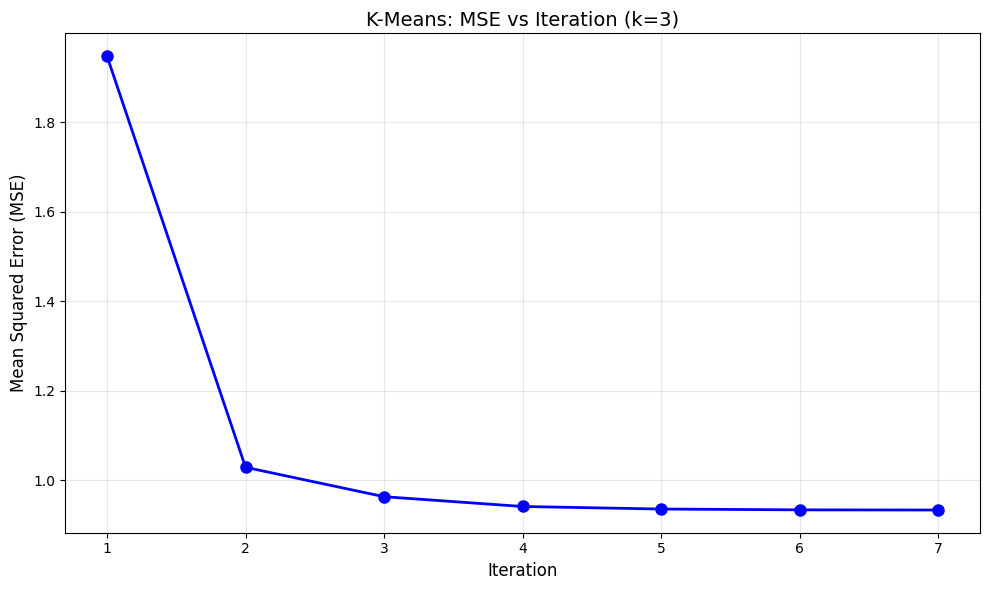

In [5]:
# Plot MSE vs Iteration
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mse_history) + 1), mse_history, 'b-o', linewidth=2, markersize=8)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('K-Means: MSE vs Iteration (k=3)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
k_values = [2, 3, 4, 5, 6, 7, 8]
final_mse_values = []
mse_histories = {}

for k in k_values:
    _, _, hist = kmeans(X_scaled, n_clusters=k, max_iter=100, random_state=42)
    final_mse_values.append(hist[-1])
    mse_histories[k] = hist
    print(f"k={k}: Final MSE = {hist[-1]:.4f}, Iterations = {len(hist)}")

Converged at iteration 3
k=2: Final MSE = 1.4824, Iterations = 3
Converged at iteration 7
k=3: Final MSE = 0.9336, Iterations = 7
Converged at iteration 10
k=4: Final MSE = 0.7637, Iterations = 10
Converged at iteration 7
k=5: Final MSE = 0.6908, Iterations = 7
Converged at iteration 9
k=6: Final MSE = 0.5392, Iterations = 9
Converged at iteration 7
k=7: Final MSE = 0.4811, Iterations = 7
Converged at iteration 8
k=8: Final MSE = 0.4486, Iterations = 8


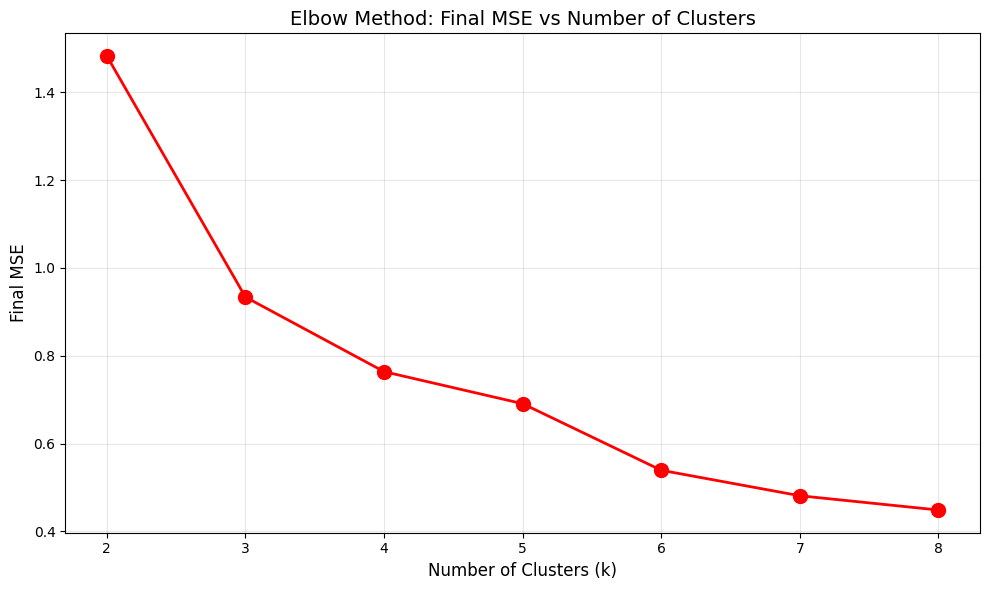

In [7]:
# Elbow Method: Final MSE vs k
plt.figure(figsize=(10, 6))
plt.plot(k_values, final_mse_values, 'r-o', linewidth=2, markersize=10)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Final MSE', fontsize=12)
plt.title('Elbow Method: Final MSE vs Number of Clusters', fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

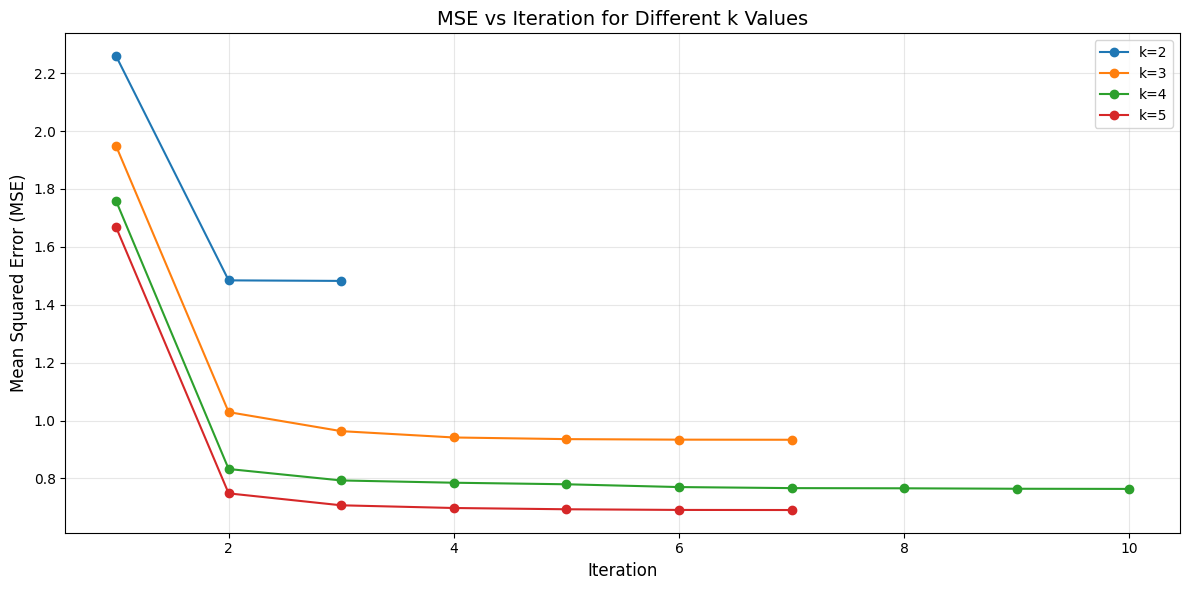

In [8]:
# MSE per iteration for different k values
plt.figure(figsize=(12, 6))
for k in [2, 3, 4, 5]:
    plt.plot(range(1, len(mse_histories[k]) + 1), mse_histories[k], '-o', label=f'k={k}', markersize=6)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('MSE vs Iteration for Different k Values', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Converged at iteration 6
Random State 0: Final MSE = 0.9393, Iterations = 6
Converged at iteration 7
Random State 10: Final MSE = 0.9393, Iterations = 7
Converged at iteration 7
Random State 42: Final MSE = 0.9336, Iterations = 7
Converged at iteration 8
Random State 100: Final MSE = 0.9336, Iterations = 8
Converged at iteration 7
Random State 200: Final MSE = 0.9336, Iterations = 7


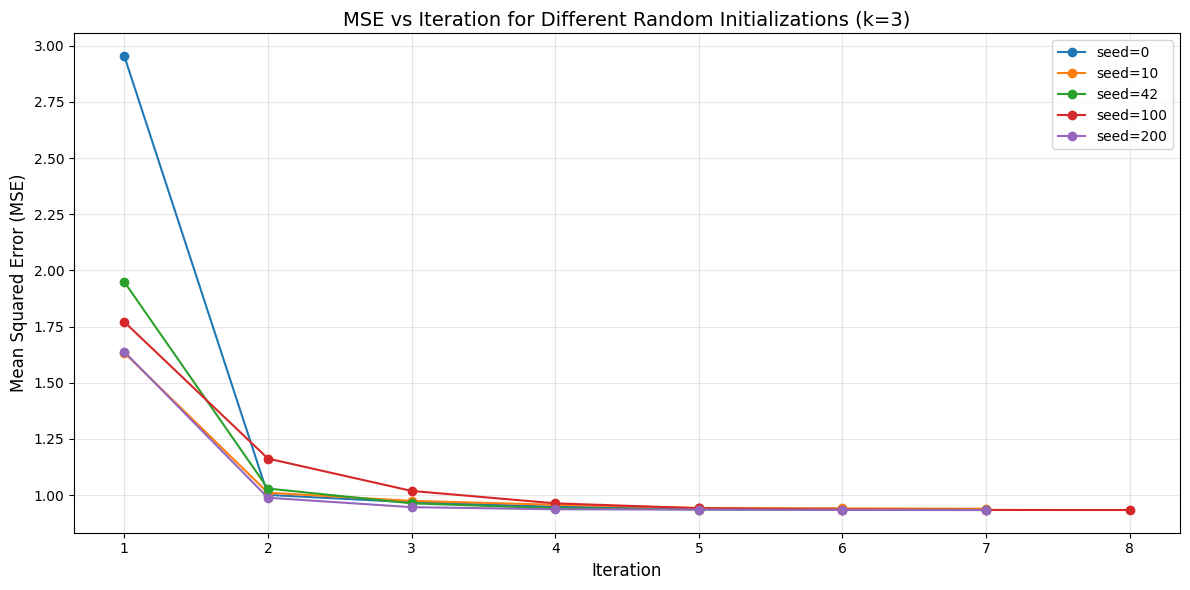

In [9]:
random_states = [0, 10, 42, 100, 200]
init_mse_histories = {}

plt.figure(figsize=(12, 6))
for rs in random_states:
    _, _, hist = kmeans(X_scaled, n_clusters=3, max_iter=100, random_state=rs)
    init_mse_histories[rs] = hist
    print(f"Random State {rs}: Final MSE = {hist[-1]:.4f}, Iterations = {len(hist)}")
    plt.plot(range(1, len(hist) + 1), hist, '-o', label=f'seed={rs}', markersize=6)

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('MSE vs Iteration for Different Random Initializations (k=3)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Converged at iteration 7


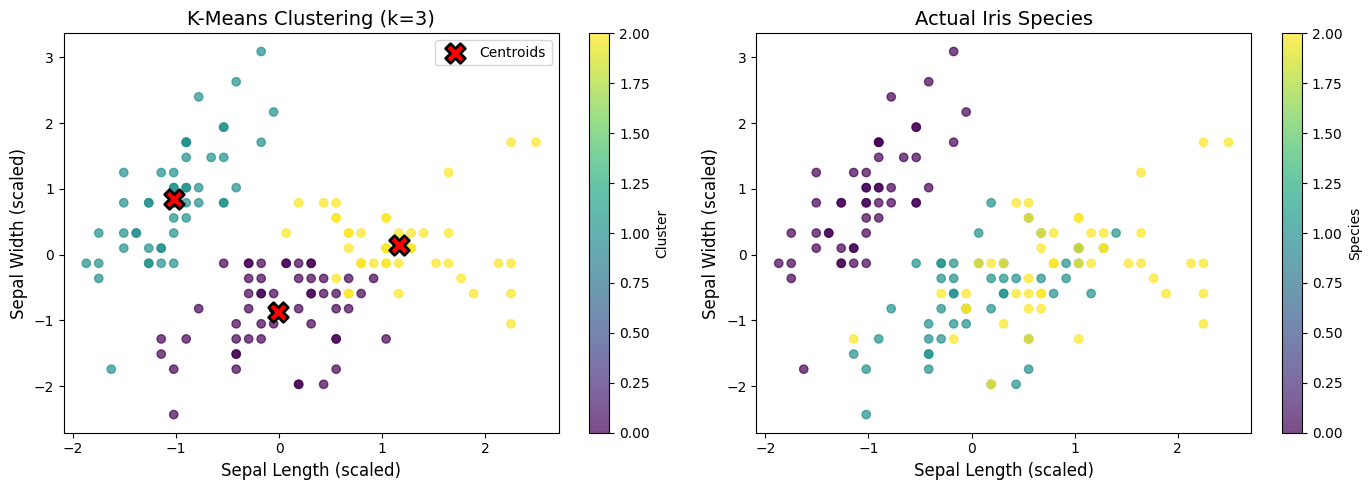

In [10]:
# Final clustering with k=3
final_centroids, final_labels, _ = kmeans(X_scaled, n_clusters=3, max_iter=100, random_state=42)

# Plot clusters using first two features
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=final_labels, cmap='viridis', alpha=0.7)
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], 
            c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroids')
plt.xlabel('Sepal Length (scaled)', fontsize=12)
plt.ylabel('Sepal Width (scaled)', fontsize=12)
plt.title('K-Means Clustering (k=3)', fontsize=14)
plt.legend()
plt.colorbar(scatter, label='Cluster')

plt.subplot(1, 2, 2)
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('Sepal Length (scaled)', fontsize=12)
plt.ylabel('Sepal Width (scaled)', fontsize=12)
plt.title('Actual Iris Species', fontsize=14)
plt.colorbar(scatter, label='Species')

plt.tight_layout()
plt.show()

In [11]:
# Summary Table
summary_data = {
    'k': k_values,
    'Final MSE': [f"{mse:.4f}" for mse in final_mse_values],
    'Iterations': [len(mse_histories[k]) for k in k_values]
}
summary_df = pd.DataFrame(summary_data)
print("Performance by Number of Clusters:")
print(summary_df.to_string(index=False))

print("\nConclusions:")
print("- As k increases, MSE decreases (more clusters = less error)")
print("- The 'elbow' in the MSE curve suggests optimal k")
print("- Different initializations can lead to different final solutions")
print("- For Iris dataset, k=3 is optimal (matching 3 species)")

Performance by Number of Clusters:
 k Final MSE  Iterations
 2    1.4824           3
 3    0.9336           7
 4    0.7637          10
 5    0.6908           7
 6    0.5392           9
 7    0.4811           7
 8    0.4486           8

Conclusions:
- As k increases, MSE decreases (more clusters = less error)
- The 'elbow' in the MSE curve suggests optimal k
- Different initializations can lead to different final solutions
- For Iris dataset, k=3 is optimal (matching 3 species)
